Importing Libaries


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the datasets


In [51]:
files = ["dataset/Components of population change - states and territories.xlsx"
         , "dataset/Population - New South Wales.xlsx"
         , "dataset/Population - states and territories.xlsx"
         ]
dataframes = []

for file in files:
    try:
        df = pd.read_excel(file, sheet_name="Data1")

        # remove top metadata rows
        df = df.iloc[9:].reset_index(drop=True)

        # create new dataframe
        new_df = pd.DataFrame()
        new_df["date"] = pd.to_datetime(df.iloc[:, 0], errors="coerce")

        # add extra columns
        new_df["year"] = new_df["date"].dt.year
        new_df["quarter"] = new_df["date"].dt.quarter
        new_df["source_file"] = file

        # add all other columns
        for i, col in enumerate(df.columns[1:]):
            name = str(col).split(";")
            measure = name[0].strip()
            state = name[1].strip() if len(name) > 1 else "unknown"

            col_name = f"{measure}_{state}".lower().replace(" ", "_")
            new_df[col_name] = pd.to_numeric(df.iloc[:, i+1], errors="coerce")

        dataframes.append(new_df)

    except Exception as e:
        print("Error:", file, e)

COMBINE DATA

In [52]:
print("\nCombining data from all files...")

final_df = pd.concat(dataframes, ignore_index=True)
final_df = final_df.dropna(subset=['date', 'year'])

print(f"Combined data shape: {final_df.shape}")
print(f"\nDate range: {final_df['date'].min()} to {final_df['date'].max()}")


Combining data from all files...
Combined data shape: (411, 42)

Date range: 1971-06-01 00:00:00 to 2025-09-01 00:00:00


In [53]:
print(f"\nData loaded from:")
for file in files:
    file_data = final_df[final_df['source_file'] == file]
    sheets = file_data['sheet_name'].unique() if 'sheet_name' in file_data.columns else ['Data1']
    print(f"  {file}: {len(file_data)} rows from sheets {list(sheets)}")


Data loaded from:
  dataset/Components of population change - states and territories.xlsx: 178 rows from sheets ['Data1']
  dataset/Population - New South Wales.xlsx: 55 rows from sheets ['Data1']
  dataset/Population - states and territories.xlsx: 178 rows from sheets ['Data1']


In [54]:
print(f"\nTotal columns available: {len(final_df.columns)}")
print(f"First 5 rows:")
final_df.head()


Total columns available: 42
First 5 rows:


,date,year,quarter,source_file,natural_increase_new_south_wales,net_overseas_migration_new_south_wales,net_interstate_migration_new_south_wales,change_over_previous_quarter_new_south_wales,natural_increase_victoria,net_overseas_migration_victoria,...,natural_increase_australian_capital_territory,net_overseas_migration_australian_capital_territory,net_interstate_migration_australian_capital_territory,change_over_previous_quarter_australian_capital_territory,natural_increase_australia,net_overseas_migration_australia,change_over_previous_quarter_australia,estimated_resident_population_male,estimated_resident_population_female,estimated_resident_population_persons
0,1981-06-01,1981,2,dataset/Components of population change - stat...,11516.0,9281.0,-6330.0,NaN,7302.0,5533.0,...,847.0,-131.0,565.0,NaN,33604.0,25575.0,NaN,NaN,NaN,NaN
1,1981-09-01,1981,3,dataset/Components of population change - stat...,9559.0,13284.0,-7768.0,14566.0,7353.0,8237.0,...,777.0,152.0,-15.0,1201.0,29580.0,34141.0,65417.0,NaN,NaN,NaN
2,1981-12-01,1981,4,dataset/Components of population change - stat...,9181.0,13295.0,-4528.0,17439.0,7191.0,8505.0,...,856.0,383.0,-824.0,702.0,29262.0,34482.0,65440.0,NaN,NaN,NaN
3,1982-03-01,1982,1,dataset/Components of population change - stat...,11081.0,12477.0,-3824.0,19225.0,8492.0,7606.0,...,842.0,419.0,-42.0,1506.0,34509.0,31376.0,67581.0,NaN,NaN,NaN
4,1982-06-01,1982,2,dataset/Components of population change - stat...,11097.0,10337.0,-3464.0,17461.0,7310.0,6796.0,...,786.0,271.0,711.0,2055.0,32735.0,28118.0,62549.0,NaN,NaN,NaN


eda

In [55]:
df_analysis = final_df.copy()

# Rename the Australia-level columns
df_analysis = df_analysis.rename(columns={
    'natural_increase_australia': 'Natural Increase',
    'net_overseas_migration_australia': 'Net Migration',
})

print("Stage 1: Initial Data Quality Check")
print(f"Shape: {df_analysis.shape}")
print(f"Missing values:\n{df_analysis.isnull().sum()}")
print(f"Data types:\n{df_analysis.dtypes}")

Stage 1: Initial Data Quality Check
Shape: (411, 42)
Missing values:
date                                                           0
year                                                           0
quarter                                                        0
source_file                                                    0
natural_increase_new_south_wales                             233
net_overseas_migration_new_south_wales                       233
net_interstate_migration_new_south_wales                     233
change_over_previous_quarter_new_south_wales                 234
natural_increase_victoria                                    233
net_overseas_migration_victoria                              233
net_interstate_migration_victoria                            233
change_over_previous_quarter_victoria                        234
natural_increase_queensland                                  233
net_overseas_migration_queensland                            233
net_interstate_migrat

In [56]:
print(df_analysis.groupby('source_file')[['Natural Increase', 'Net Migration']].count())

                                                    Natural Increase  \
source_file                                                            
dataset/Components of population change - state...               178   
dataset/Population - New South Wales.xlsx                          0   
dataset/Population - states and territories.xlsx                   0   

                                                    Net Migration  
source_file                                                        
dataset/Components of population change - state...            178  
dataset/Population - New South Wales.xlsx                       0  
dataset/Population - states and territories.xlsx                0  


In [ ]:
df_analysis.isnull().sum()


date                                                           0
year                                                           0
quarter                                                        0
source_file                                                    0
natural_increase_new_south_wales                             233
net_overseas_migration_new_south_wales                       233
net_interstate_migration_new_south_wales                     233
change_over_previous_quarter_new_south_wales                 234
natural_increase_victoria                                    233
net_overseas_migration_victoria                              233
net_interstate_migration_victoria                            233
change_over_previous_quarter_victoria                        234
natural_increase_queensland                                  233
net_overseas_migration_queensland                            233
net_interstate_migration_queensland                          233
change_over_previous_quar

In [63]:
# Check how many rows each source file contributes
print("=== Rows per source file ===")
print(df_analysis.groupby('source_file')['date'].count())

# Check if dates overlap between files
print("\n=== Date ranges per source file ===")
for file, group in df_analysis.groupby('source_file'):
    print(f"\n{file.split('/')[-1]}:")
    print(f"  Rows: {len(group)}")
    print(f"  Date range: {group['date'].min().date()} → {group['date'].max().date()}")

# Check for duplicate dates (would confirm serial stacking vs proper merge)
print("\n=== Duplicate dates ===")
print(f"Total rows: {len(df_analysis)}")
print(f"Unique dates: {df_analysis['date'].nunique()}")
print(f"Duplicate date count: {df_analysis['date'].duplicated().sum()}")

=== Rows per source file ===
source_file
dataset/Components of population change - states and territories.xlsx    178
dataset/Population - New South Wales.xlsx                                 55
dataset/Population - states and territories.xlsx                         178
Name: date, dtype: int64

=== Date ranges per source file ===

Components of population change - states and territories.xlsx:
  Rows: 178
  Date range: 1981-06-01 → 2025-09-01

Population - New South Wales.xlsx:
  Rows: 55
  Date range: 1971-06-01 → 2025-06-01

Population - states and territories.xlsx:
  Rows: 178
  Date range: 1981-06-01 → 2025-09-01

=== Duplicate dates ===
Total rows: 411
Unique dates: 188
Duplicate date count: 223


In [64]:
# Inspect each raw dataframe's columns and date format
for i, df in enumerate(dataframes):
    print(f"\n=== Dataframe {i+1} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"Sample dates: {df['date'].head(3).tolist()}")


=== Dataframe 1 ===
Shape: (178, 39)
Columns: ['date', 'year', 'quarter', 'source_file', 'natural_increase_new_south_wales', 'net_overseas_migration_new_south_wales', 'net_interstate_migration_new_south_wales', 'change_over_previous_quarter_new_south_wales', 'natural_increase_victoria', 'net_overseas_migration_victoria', 'net_interstate_migration_victoria', 'change_over_previous_quarter_victoria', 'natural_increase_queensland', 'net_overseas_migration_queensland', 'net_interstate_migration_queensland', 'change_over_previous_quarter_queensland', 'natural_increase_south_australia', 'net_overseas_migration_south_australia', 'net_interstate_migration_south_australia', 'change_over_previous_quarter_south_australia', 'natural_increase_western_australia', 'net_overseas_migration_western_australia', 'net_interstate_migration_western_australia', 'change_over_previous_quarter_western_australia', 'natural_increase_tasmania', 'net_overseas_migration_tasmania', 'net_interstate_migration_tasmania',

In [65]:
# Merge Dataframe 1 (population change components) with Dataframe 3 (quarterly population)
# Drop source_file from both before merging to avoid collision
df1_clean = dataframes[0].drop(columns=['source_file'])
df3_clean = dataframes[2].drop(columns=['source_file'])

df_analysis = df1_clean.merge(df3_clean, on=['date', 'year', 'quarter'], how='inner')

# Rename Australia-level columns
df_analysis = df_analysis.rename(columns={
    'natural_increase_australia': 'Natural Increase',
    'net_overseas_migration_australia': 'Net Migration',
})

print("Stage 1: Initial Data Quality Check")
print(f"Shape: {df_analysis.shape}")
print(f"Unique dates: {df_analysis['date'].nunique()}")
print(f"Missing values:\n{df_analysis.isnull().sum()}")

Stage 1: Initial Data Quality Check
Shape: (178, 41)
Unique dates: 178
Missing values:
date                                                         0
year                                                         0
quarter                                                      0
natural_increase_new_south_wales                             0
net_overseas_migration_new_south_wales                       0
net_interstate_migration_new_south_wales                     0
change_over_previous_quarter_new_south_wales                 1
natural_increase_victoria                                    0
net_overseas_migration_victoria                              0
net_interstate_migration_victoria                            0
change_over_previous_quarter_victoria                        1
natural_increase_queensland                                  0
net_overseas_migration_queensland                            0
net_interstate_migration_queensland                          0
change_over_previous_quarter_qu

In [67]:
# Only 1 missing value per change_over_previous_quarter column - this is the first row
# which naturally has no previous quarter to compare to. Drop that single row.
df_analysis = df_analysis.dropna(subset=['change_over_previous_quarter_australia'])



In [68]:
# Detect outliers using IQR method on Natural Increase
Q1 = df_analysis['Natural Increase'].quantile(0.25)
Q3 = df_analysis['Natural Increase'].quantile(0.75)
IQR = Q3 - Q1
outliers = (df_analysis['Natural Increase'] < Q1 - 1.5*IQR) | \
           (df_analysis['Natural Increase'] > Q3 + 1.5*IQR)

print(f"Shape after cleaning: {df_analysis.shape}")  # Should be (177, 41)
print(f"Outliers found in Natural Increase: {outliers.sum()}")
print(f"Any missing values remaining: {df_analysis.isnull().sum().sum()}")

Shape after cleaning: (177, 41)
Outliers found in Natural Increase: 0
Any missing values remaining: 0


In [71]:
# Natural Increase - safe to log1p directly (all positive)
df_analysis['NI_Log'] = np.log1p(df_analysis['Natural Increase'])

# Net Migration - shift first to make all values positive before log
nm_shift = abs(df_analysis['Net Migration'].min()) + 1
df_analysis['NM_Log'] = np.log1p(df_analysis['Net Migration'] + nm_shift)

print("New columns added:")
print(df_analysis[['Natural Increase', 'NI_Log', 'Net Migration', 'NM_Log']].head())
print(f"\nNI_Log min: {df_analysis['NI_Log'].min()}")
print(f"NM_Log min: {df_analysis['NM_Log'].min()}")
print(f"Any NaNs in log columns: {df_analysis[['NI_Log', 'NM_Log']].isnull().sum().sum()}")

New columns added:
   Natural Increase     NI_Log  Net Migration     NM_Log
1             29580  10.294888          34141  11.247579
2             29262  10.284079          34482  11.252015
3             34509  10.449004          31376  11.210860
4             32735  10.396231          28118  11.165791
5             26367  10.179906          26893  11.148305

NI_Log min: 10.037843605035206
NM_Log min: 0.6931471805599453
Any NaNs in log columns: 0


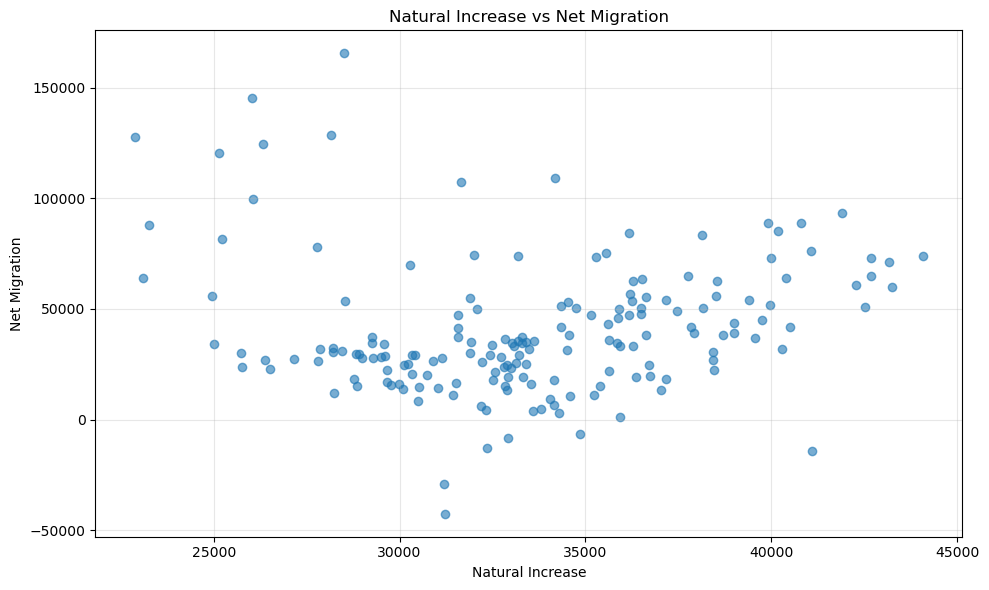

In [72]:
plt.figure(figsize=(10, 6))
plt.scatter(df_analysis['Natural Increase'], df_analysis['Net Migration'], alpha=0.6)
plt.xlabel('Natural Increase')
plt.ylabel('Net Migration')
plt.title('Natural Increase vs Net Migration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

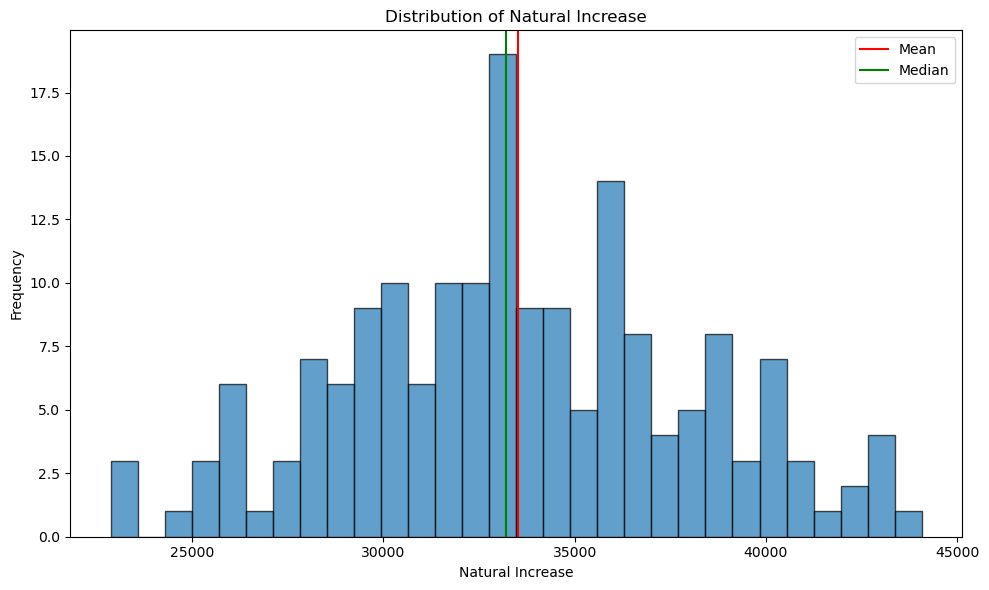

In [73]:
plt.figure(figsize=(10, 6))
plt.hist(df_analysis['Natural Increase'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_analysis['Natural Increase'].mean(), color='red', label='Mean')
plt.axvline(df_analysis['Natural Increase'].median(), color='green', label='Median')
plt.xlabel('Natural Increase')
plt.ylabel('Frequency')
plt.title('Distribution of Natural Increase')
plt.legend()
plt.tight_layout()
plt.show()

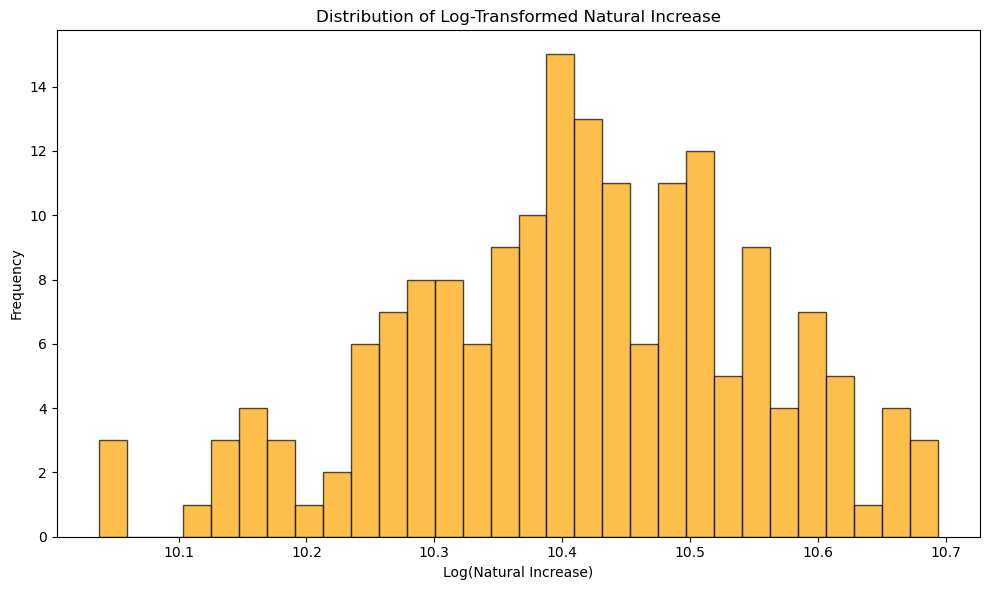

In [74]:
plt.figure(figsize=(10, 6))
plt.hist(df_analysis['NI_Log'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Log(Natural Increase)')
plt.ylabel('Frequency')
plt.title('Distribution of Log-Transformed Natural Increase')
plt.tight_layout()
plt.show()

Total numeric columns: 42
['year', 'quarter', 'natural_increase_new_south_wales', 'net_overseas_migration_new_south_wales', 'net_interstate_migration_new_south_wales', 'change_over_previous_quarter_new_south_wales', 'natural_increase_victoria', 'net_overseas_migration_victoria', 'net_interstate_migration_victoria', 'change_over_previous_quarter_victoria', 'natural_increase_queensland', 'net_overseas_migration_queensland', 'net_interstate_migration_queensland', 'change_over_previous_quarter_queensland', 'natural_increase_south_australia', 'net_overseas_migration_south_australia', 'net_interstate_migration_south_australia', 'change_over_previous_quarter_south_australia', 'natural_increase_western_australia', 'net_overseas_migration_western_australia', 'net_interstate_migration_western_australia', 'change_over_previous_quarter_western_australia', 'natural_increase_tasmania', 'net_overseas_migration_tasmania', 'net_interstate_migration_tasmania', 'change_over_previous_quarter_tasmania', 'n

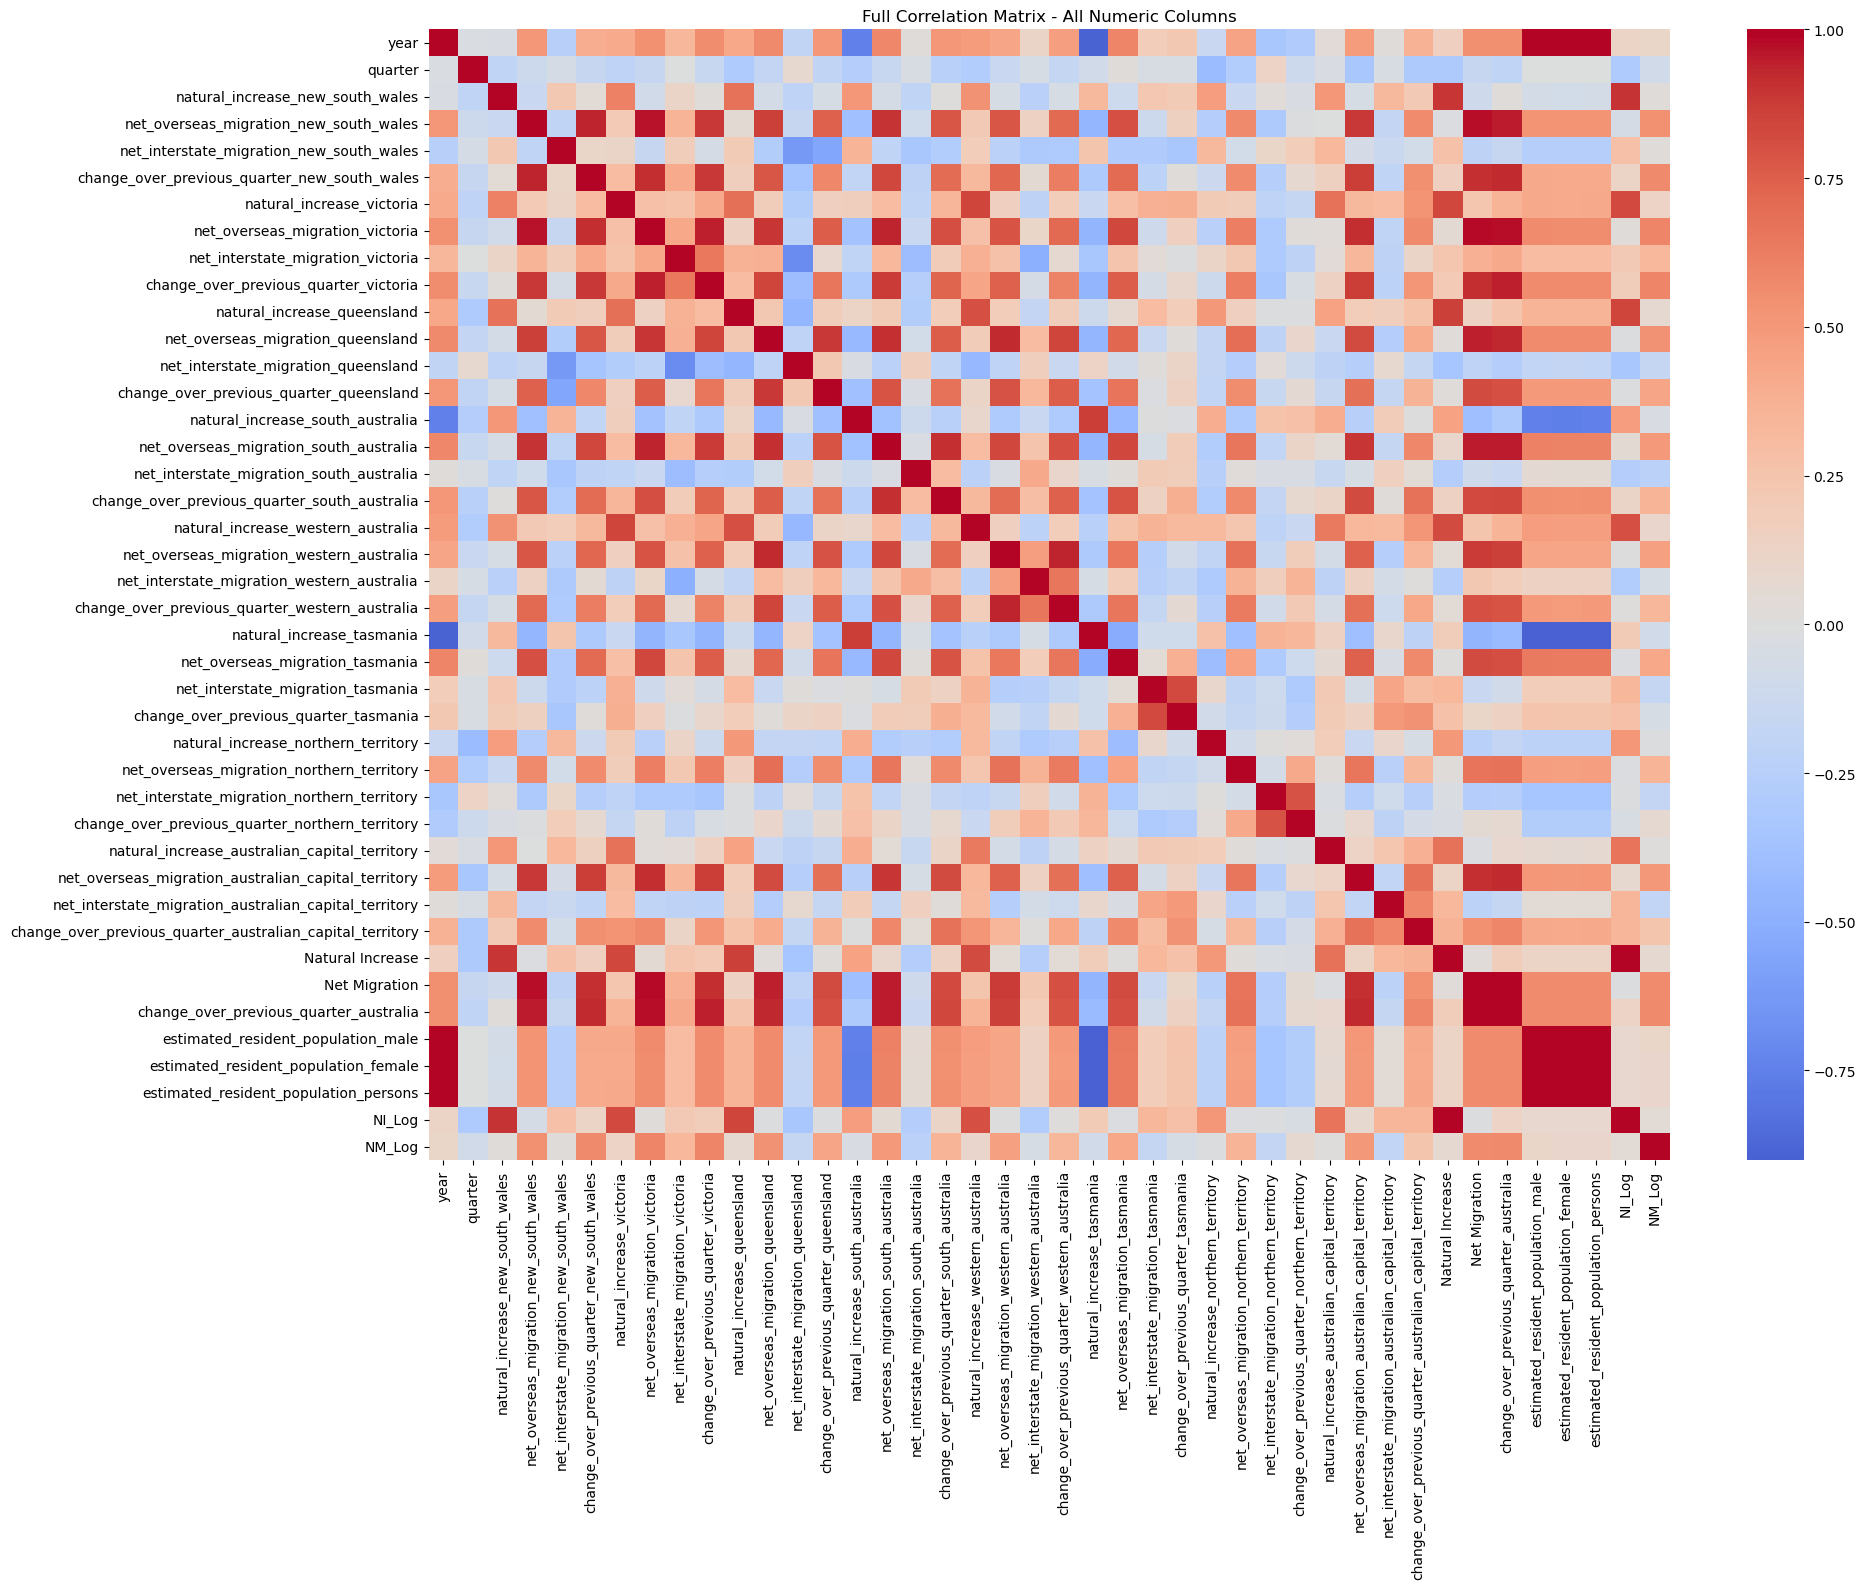


=== Top correlations with Natural Increase ===
Natural Increase                                             1.000000
NI_Log                                                       0.996104
natural_increase_new_south_wales                             0.889689
natural_increase_queensland                                  0.861998
natural_increase_victoria                                    0.838512
natural_increase_western_australia                           0.818917
natural_increase_australian_capital_territory                0.667656
natural_increase_northern_territory                          0.500717
natural_increase_south_australia                             0.453776
change_over_previous_quarter_australian_capital_territory    0.368345
Name: Natural Increase, dtype: float64

=== Top correlations with Net Migration ===
Net Migration                                          1.000000
change_over_previous_quarter_australia                 0.988266
net_overseas_migration_victoria         

In [78]:
# Get all numeric columns
numeric_cols = df_analysis.select_dtypes(include='number').columns.tolist()
print(f"Total numeric columns: {len(numeric_cols)}")
print(numeric_cols)

# Full correlation matrix heatmap
plt.figure(figsize=(20, 16))
corr_matrix = df_analysis[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)  # annot=False since too many columns
plt.title('Full Correlation Matrix - All Numeric Columns')
plt.tight_layout()
plt.show()

# Print strongest correlations with Natural Increase
print("\n=== Top correlations with Natural Increase ===")
print(corr_matrix['Natural Increase'].sort_values(ascending=False).head(10))

print("\n=== Top correlations with Net Migration ===")
print(corr_matrix['Net Migration'].sort_values(ascending=False).head(10))

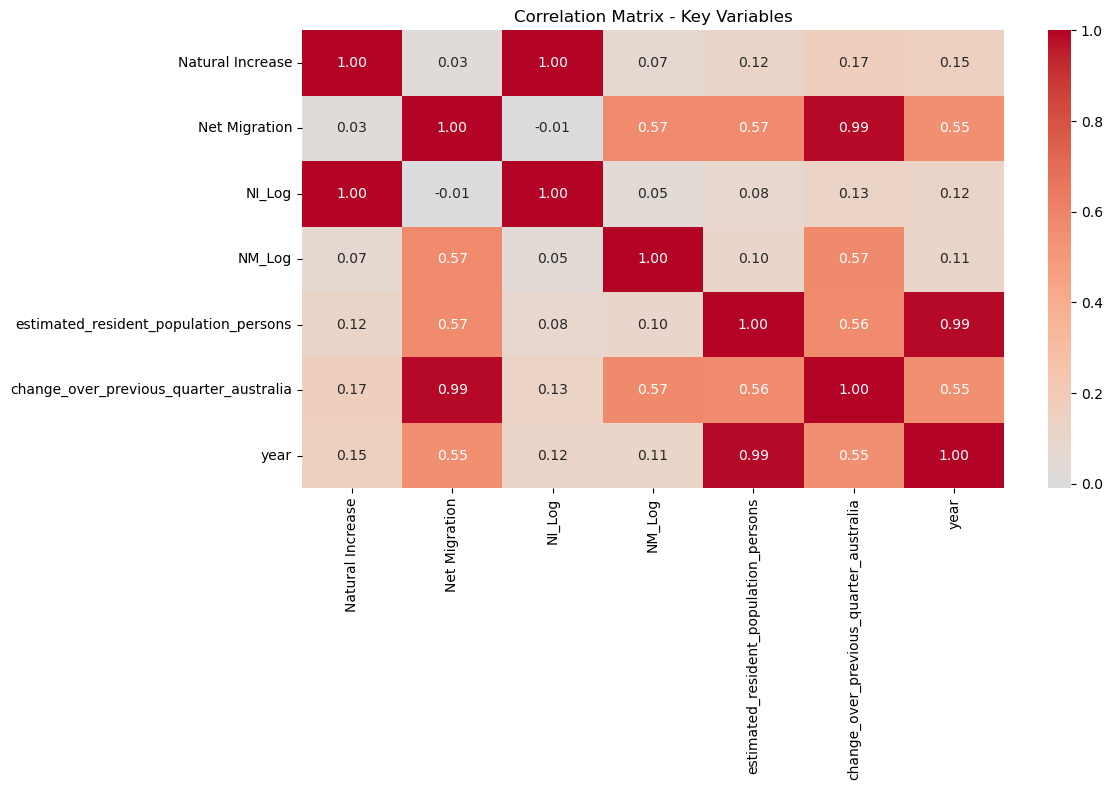

In [80]:
plt.figure(figsize=(12, 8))

key_cols = [
    'Natural Increase', 'Net Migration',
    'NI_Log', 'NM_Log',
    'estimated_resident_population_persons',
    'change_over_previous_quarter_australia',
    'year'
]

corr_matrix = df_analysis[key_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Variables')
plt.tight_layout()
plt.show()

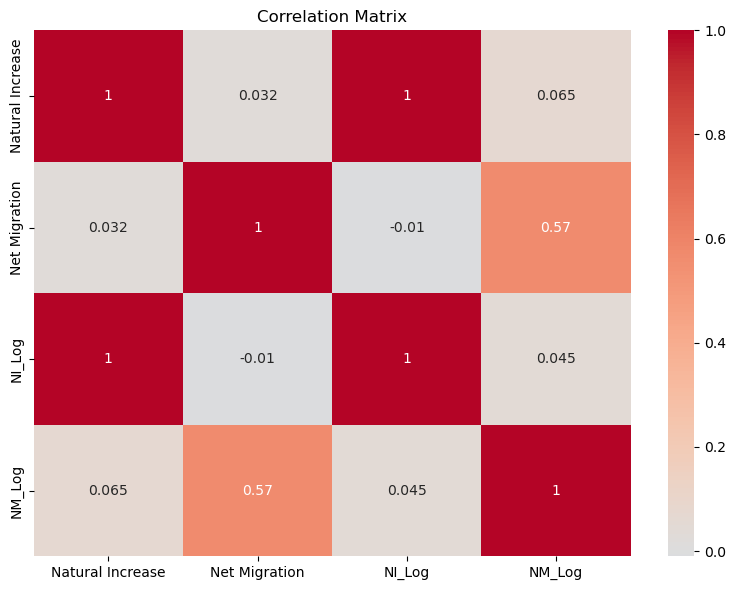

In [77]:
plt.figure(figsize=(8, 6))
corr_matrix = df_analysis[['Natural Increase', 'Net Migration', 'NI_Log', 'NM_Log']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

regression analysis

In [58]:
print("Preparing data for regression analysis...")

natural_increase_cols = [col for col in final_df.columns if 'natural_increase' in col]
net_migration_cols = [col for col in final_df.columns if 'net_overseas_migration' in col]
net_interstate_cols = [col for col in final_df.columns if 'net_interstate_migration' in col]

print(f"Found {len(natural_increase_cols)} natural increase columns")
print(f"Found {len(net_migration_cols)} net overseas migration columns")
print(f"Found {len(net_interstate_cols)} net interstate migration columns")

Preparing data for regression analysis...
Found 9 natural increase columns
Found 9 net overseas migration columns
Found 8 net interstate migration columns


In [59]:
model_data = pd.DataFrame({
    'date': final_df['date'],
    'year': final_df['year'],
    'quarter': final_df['quarter']
})

model_data['natural_increase_au'] = final_df[natural_increase_cols].mean(axis=1)
model_data['net_overseas_migration_au'] = final_df[net_migration_cols].mean(axis=1)
model_data['net_interstate_migration_au'] = final_df[net_interstate_cols].mean(axis=1)

model_data = model_data.dropna()

In [60]:
print(f"Model data shape: {model_data.shape}")
model_data.head(10)

Model data shape: (178, 6)


,date,year,quarter,natural_increase_au,net_overseas_migration_au,net_interstate_migration_au
0,1981-06-01,1981,2,7467.555556,5617.666667,0.0
1,1981-09-01,1981,3,6573.333333,7586.888889,0.0
2,1981-12-01,1981,4,6502.666667,7662.666667,0.0
3,1982-03-01,1982,1,7668.666667,6972.444444,0.0
4,1982-06-01,1982,2,7274.444444,6248.444444,0.0
5,1982-09-01,1982,3,5859.333333,5976.222222,0.0
6,1982-12-01,1982,4,7004.666667,3626.888889,0.0
7,1983-03-01,1983,1,8081.333333,4269.777778,0.0
8,1983-06-01,1983,2,7687.111111,2414.888889,0.0
9,1983-09-01,1983,3,6688.444444,3032.000000,0.0


Visualization D1: Residuals vs Fitted

In [ ]:
# Diagnostic plot for Model 1
plt.figure(figsize=(10, 6))
plt.scatter(pred1, residuals1, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values - Model 1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'pred1' is not defined

<Figure size 1000x600 with 0 Axes>

Visualization D2: Q-Q Plot

In [ ]:
# Q-Q plot for Model 2
plt.figure(figsize=(10, 6))
stats.probplot(residuals2, dist="norm", plot=plt)
plt.title('Q-Q Plot - Model 2 Residuals')
plt.tight_layout()
plt.show()

Visualization D3: Scale-Location Plot

In [ ]:
# Scale-location plot for Model 3
plt.figure(figsize=(10, 6))
std_residuals3 = residuals3 / np.std(residuals3)
plt.scatter(pred3, np.sqrt(np.abs(std_residuals3)), alpha=0.6)
plt.xlabel('Fitted Values')
plt.ylabel('√|Standardized Residuals|')
plt.title('Scale-Location Plot - Model 3')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visualization D4: Residuals Histogram

In [ ]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals1, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - Model 1')
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

Visualization D5: Predicted vs Actual

In [ ]:
# Predictions comparison
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred2, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual - Model 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visualization D6: Model Comparison

In [ ]:
# Compare all 3 models
models = ['Model 1', 'Model 2', 'Model 3']
r2_scores = [r2_m1, r2_m2, r2_m3]
rmse_scores = [rmse_m1, rmse_m2, rmse_m3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(models, r2_scores, color=['green', 'orange', 'red'], alpha=0.7)
ax1.set_ylabel('R² Score')
ax1.set_title('Model Comparison - R² Scores')
ax1.set_ylim(0, 1)

ax2.bar(models, rmse_scores, color=['green', 'orange', 'red'], alpha=0.7)
ax2.set_ylabel('RMSE')
ax2.set_title('Model Comparison - RMSE')

plt.tight_layout()
plt.show()